# Convolutional Neural Networks for Image Classification
## Training a CNN From Scratch

In this notebook, we train an **AlexNet** architecture from scratch on the **CIFAR-10** dataset using PyTorch.  
The network is initialised with random weights and trained iteratively until convergence.

### 1. Imports & Device Configuration

In [2]:
# Basic imports
import time, os, sys, numpy as np
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torchsummary import summary
import time, os, sys, numpy as np
# Test if GPU is avaliable, if not, use cpu instead
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n = torch.cuda.device_count()
devices_ids= list(range(n))

### 2. Data Loading & Helper Functions

- `load_data_cifar10` — downloads CIFAR-10 and wraps it in PyTorch `DataLoader` objects.
- `evaluate_accuracy` — computes accuracy and loss on a given dataset split.
- `train_validate` — runs the full training loop and reports metrics per epoch.

In [3]:
# In this lab session, we will use the CIFAR10 dataset with the assistance of a DataLoader.
# The DataLoader serves as a crucial function designed to load data seamlessly into the model,
# whether it be for training or inference purposes.

import os
import sys
import time
import torch
import torchvision

def load_data_cifar10(batch_size, resize=None, root=os.path.join(
    '~', '.pytorch', 'datasets', 'fashion-mnist')):
    """Download the Cifar10 dataset and then load into memory."""
    root = os.path.expanduser(root)
    transformer = []
    if resize:
        transformer += [torchvision.transforms.Resize(resize)]
    transformer += [torchvision.transforms.ToTensor()]
    transformer = torchvision.transforms.Compose(transformer)

    mnist_train = torchvision.datasets.CIFAR10(
        root=root, train=True, download=True, transform=transformer)
    mnist_test = torchvision.datasets.CIFAR10(
        root=root, train=False, download=True, transform=transformer)

    num_workers = 0 if sys.platform.startswith('win32') else 4

    train_iter = torch.utils.data.DataLoader(
        mnist_train, batch_size, shuffle=True,
        num_workers=num_workers)

    test_iter = torch.utils.data.DataLoader(
        mnist_test, batch_size, shuffle=False,
        num_workers=num_workers)

    return train_iter, test_iter


# Function used to compute accuracy
def evaluate_accuracy(data_iter, net, loss):
    """Evaluate accuracy of a model on the given data set."""
    acc_sum, n, l = torch.Tensor([0]), 0, 0
    net.eval()
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l += loss(y_hat, y).sum()
            acc_sum += (y_hat.argmax(axis=1) == y).sum().item()
            n += y.size()[0]
    return acc_sum.item() / n, l.item() / len(data_iter)


# Function used for network training and validation
def train_validate(net, train_iter, test_iter, batch_size, trainer, loss,
                   num_epochs):
    print('training on', device)
    history = []
    for epoch in range(num_epochs):
        net.train()
        train_l_sum, train_acc_sum, n, start = 0.0, 0.0, 0, time.time()

        for X, y in train_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            trainer.zero_grad()
            l = loss(y_hat, y).sum()
            l.backward()
            trainer.step()

            train_l_sum += l.item()
            train_acc_sum += (y_hat.argmax(axis=1) == y).sum().item()
            n += y.size()[0]

        test_acc, test_loss = evaluate_accuracy(test_iter, net, loss)
        train_loss = train_l_sum / len(train_iter)
        train_acc = train_acc_sum / n
        history.append({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'test_loss': test_loss,
            'test_acc': test_acc,
        })
        print('epoch %d, train loss %.4f, train acc %.3f, test loss %.4f, '
              'test acc %.3f, time %.1f sec'
              % (epoch + 1, train_loss, train_acc, test_loss,
                 test_acc, time.time() - start))
    return history

### 3. AlexNet Architecture & Training

AlexNet consists of **5 convolutional layers** followed by **3 fully-connected layers**.  
The network is adapted here for CIFAR-10 (10 output classes instead of the original 1000).

| Layer | Type | Output Shape | Params |
|-------|------|-------------|--------|
| conv1 | Conv 11×11, s=4 | 55×55×96 | 34,944 |
| maxpool1 | MaxPool 3×3, s=2 | 27×27×96 | — |
| conv2 | Conv 5×5, p=2 | 27×27×256 | 614,656 |
| maxpool2 | MaxPool 3×3, s=2 | 13×13×256 | — |
| conv3 | Conv 3×3, p=1 | 13×13×384 | 885,120 |
| conv4 | Conv 3×3, p=1 | 13×13×384 | 1,327,488 |
| conv5 | Conv 3×3, p=1 | 13×13×256 | 884,992 |
| maxpool5 | MaxPool 3×3, s=2 | 6×6×256 | — |
| fc6 | Linear + Dropout | 4096 | 37,752,832 |
| fc7 | Linear + Dropout | 4096 | 16,781,312 |
| fc8 | Linear | 10 | 40,970 |

In [4]:
# parameters: number of epochs, learning rate,
# batch size, and weight decay lambda
num_epochs, lr, batch_size, wd_lambda = 20, 0.001, 100, 0.0001

import torch.nn as nn
import torch.optim as optim

class AlexNet(nn.Module):
    def __init__(self, input_channels, classes=10, **kwargs):
        super(AlexNet, self).__init__(**kwargs)

        # Convolutional layers
        self.convs = nn.Sequential(
            nn.Conv2d(input_channels, 96, kernel_size=11, stride=4, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2)
        )

        # Fully-connected layers
        self.features = nn.Sequential(
            nn.Flatten(),

            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(4096, classes)
        )

    def forward(self, x):
        x = self.convs(x)      # Convolution layers
        x = self.features(x)   # Fully Connected layers
        return x


# Model instance for RGB images and 10 classes
net = AlexNet(3, 10)

# Sending model to device
net.to(device)

print(summary(net, (3, 227, 227)))

# loss function
loss = nn.CrossEntropyLoss()

# loading data
train_iter, test_iter = load_data_cifar10(batch_size, resize=227)

# trainer
trainer = optim.Adam(net.parameters(), lr=lr, weight_decay=wd_lambda)

# training and validation
history = train_validate(net, train_iter, test_iter, batch_size, trainer, loss, num_epochs)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 96, 55, 55]          34,944
              ReLU-2           [-1, 96, 55, 55]               0
         MaxPool2d-3           [-1, 96, 27, 27]               0
            Conv2d-4          [-1, 256, 27, 27]         614,656
              ReLU-5          [-1, 256, 27, 27]               0
         MaxPool2d-6          [-1, 256, 13, 13]               0
            Conv2d-7          [-1, 384, 13, 13]         885,120
              ReLU-8          [-1, 384, 13, 13]               0
            Conv2d-9          [-1, 384, 13, 13]       1,327,488
             ReLU-10          [-1, 384, 13, 13]               0
           Conv2d-11          [-1, 256, 13, 13]         884,992
             ReLU-12          [-1, 256, 13, 13]               0
        MaxPool2d-13            [-1, 256, 6, 6]               0
          Flatten-14                 [-

### 4. Training Curves

Loss and accuracy over epochs. With `num_epochs=1` only a single data point is shown — increase epochs to see the learning trend.

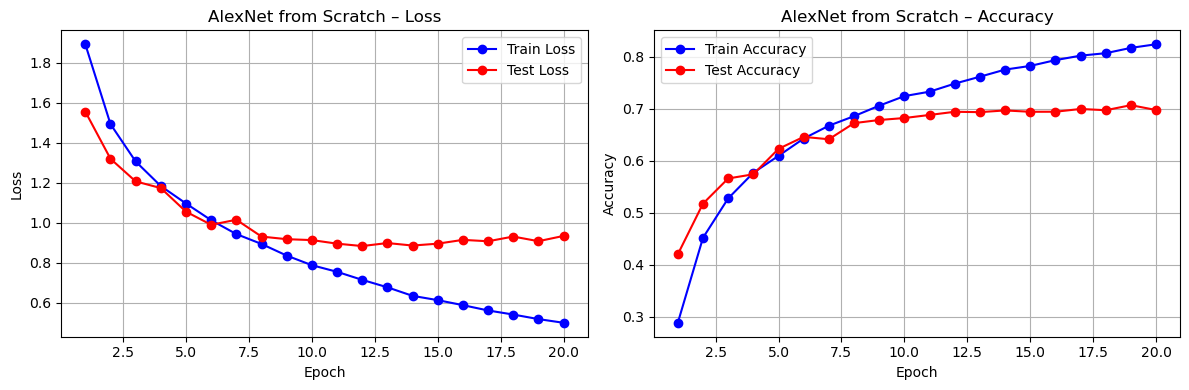

In [5]:
import matplotlib.pyplot as plt

epochs     = [h['epoch']      for h in history]
train_loss = [h['train_loss'] for h in history]
test_loss  = [h['test_loss']  for h in history]
train_acc  = [h['train_acc']  for h in history]
test_acc   = [h['test_acc']   for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, train_loss, 'b-o', label='Train Loss')
ax1.plot(epochs, test_loss,  'r-o', label='Test Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('AlexNet from Scratch – Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs, train_acc, 'b-o', label='Train Accuracy')
ax2.plot(epochs, test_acc,  'r-o', label='Test Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('AlexNet from Scratch – Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()